# 00 — Course map and the jet-space view

**Level:** first contact → conceptual graduate bridge  
**Question:** *What is a physics-informed neural network?*

By the end you will be able to:

1. distinguish a neural **field** from a neural operator and a time-stepper;
2. derive the generic PINN objective from a differential equation;
3. explain collocation as stochastic quadrature, not labeled data;
4. use the **jet-space view** to connect strong, weak, forward, and inverse PINNs.

> **Central claim.** A PINN is constrained scientific inference over a continuous
> trial field. Automatic differentiation lifts that field into derivative space;
> physics, boundary conditions, and measurements interrogate the same field with
> different virtual instruments.

In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import numpy as np

## What is a field equation?

Let $x\in\Omega\subset\mathbb R^d$ denote independent variables (space,
time, parameters) and let

$
u:\Omega\longrightarrow\mathbb R^m
$

be an unknown field. A general differential model is

$
\mathcal F\!\left(x,u,\nabla u,\nabla^2u,\ldots;\lambda\right)=0
\quad\text{in }\Omega,
\qquad
\mathcal B[u]=g\quad\text{on }\partial\Omega,
$

where $\lambda$ contains known or unknown physical parameters.

**Forward problem:** infer $u$ from $\mathcal F,\mathcal B,g,\lambda$ .  
**Inverse problem:** infer some of $(u,\lambda)$ using the equations and
measurements $y_i\approx\mathcal H_i[u]$.

A classical numerical method chooses a finite trial representation (for example, finite
elements, finite volumes, spectral coefficients, etc.) and determines its degrees of
freedom. A PINN makes a different trial choice:

$
u(x)\approx u_\theta(x)=\operatorname{NN}(x;\theta).
$

The network is not the physics. It is the **trial space** in which we search.

## The view: lift the field into jet space

The order-$k$ **jet** of a smooth field records its local value and all
derivatives through order $k$:

$
J^k u(x)=\big(u(x),\partial_{x_1}u(x),\ldots,\partial^\alpha u(x)\big)_{|\alpha|\le k}.
$

For an order-$k$ PDE, the differential equation becomes an algebraic condition
in jet coordinates:

$
\mathcal F\big(x,J^k u(x);\lambda\big)=0.
$

Thus $\mathcal F=0$ defines a **physics manifold** inside jet space. Automatic
differentiation lifts the neural field $u_\theta$ to $J^k u_\theta$. Training
tries to place the lifted graph on that manifold while satisfying anchors from
boundaries, initial conditions, and data.

This is more useful than “add physics to the loss” because it exposes five
independently designed objects:

| Object | Mathematical role | Typical failure |
|---|---|---|
| trial field $u_\theta$ | approximation class | spectral bias / wrong regularity |
| physics operator $\mathcal F$ | constraint manifold | wrong/incomplete model |
| probe measure $\mu$ | norm and quadrature | missed layers / aliasing |
| constraint mechanism | hard map or penalty | imbalance / infeasibility |
| optimizer | searches parameters | stiffness / local plateaus |

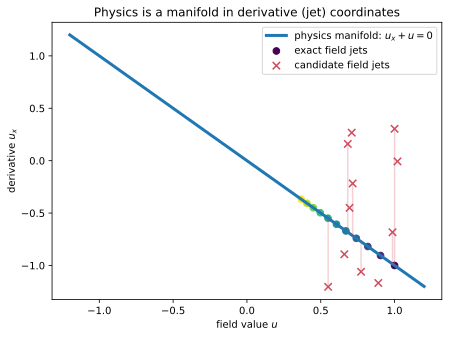

In [5]:
# A jet-space picture for the ODE u_x + u = 0.
# In coordinates (u, u_x), the physics manifold is the line u_x = -u.
u_coord = np.linspace(-1.2, 1.2, 300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(u_coord, -u_coord, lw=3, label=r"physics manifold: $u_x+u=0$")

x = np.linspace(0, 1, 11)
u_good = np.exp(-x)
ux_good = -np.exp(-x)
u_bad = 1 - 0.45*x + 0.08*np.sin(3*np.pi*x)
ux_bad = -0.45 + 0.24*np.pi*np.cos(3*np.pi*x)

ax.scatter(u_good, ux_good, c=x, cmap="viridis", s=45, label="exact field jets")
ax.scatter(u_bad, ux_bad, marker="x", c="#d1495b", s=55, label="candidate field jets")
for ug, uxg, ub, uxb in zip(u_good[::2], ux_good[::2], u_bad[::2], ux_bad[::2]):
    ax.plot([ub, ub], [uxb, -ub], color="#d1495b", alpha=.25)

ax.set(xlabel=r"field value $u$", ylabel=r"derivative $u_x$",
       title="Physics is a manifold in derivative (jet) coordinates")
ax.legend();

## From continuous constraint to trainable objective

Define the strong residual

$
r_\theta(x)=\mathcal F\big(x,J^k u_\theta(x);\lambda\big).
$

A continuous least-squares objective is

$
\mathcal J_{\rm phys}(\theta)
=\int_\Omega \|r_\theta(x)\|_2^2\,d\mu(x).
$

For collocation points $x_r^{(i)}\sim\mu $, Monte Carlo or quadrature gives

$
\widehat{\mathcal J}_{\rm phys}
=\frac1{N_r}\sum_{i=1}^{N_r}\|r_\theta(x_r^{(i)})\|_2^2.
$

These are **zero-labeled virtual measurements**: the label is the residual value
required by the model, not a measured solution value.

A standard soft-constraint PINN minimizes

$
\mathcal L(\theta,\lambda)=
w_r\widehat{\mathcal J}_{\rm phys}
+w_b\widehat{\mathcal J}_{\rm boundary}
+w_0\widehat{\mathcal J}_{\rm initial}
+w_d\widehat{\mathcal J}_{\rm data}.
$

Every weight changes the optimization problem. The weights are not harmless
cosmetics, especially when the residual components have different physical units.

## Four formulations hiding under the name “PINN”

**Strong collocation:** minimize pointwise $\mathcal F[u_\theta]$.  
**Weak/variational:** require $\int r_\theta v_j=0$ for test functions $v_j$.  
**Energy/Ritz:** minimize an energy whose Euler–Lagrange equation is the PDE.  
**Discrete-time:** embed a time-integrator or learned update map.

They share a neural trial field but do **not** impose the same topology, derivative
order, conservation behavior, or conditioning. 

### What a PINN is not

- It is**not automatically exact** because a law appears in the loss.
- It is not mesh-free in the sense of being discretization-free: collocation and
  quadrature points are a discretization of the objective.
- It is **not automatically superior to finite elements or finite volumes** (this is a common point of misconception).
- It usually learns one solution field. A neural operator learns a map between
  functions and can amortize work over a family of PDE instances.

## 5. The course route

```text
derivatives → neural fields → strong residual → constraints & units
     → time/causality → inverse inference → weak/energy forms
     → failure diagnostics → research-grade evidence
```

At each stage ask the same five questions:

1. **Representation:** What fields can $u_\theta$ express smoothly?
2. **Constraint:** What continuous statement should be satisfied?
3. **Measure:** Where and in what norm is it tested?
4. **Optimization:** Which terms compete through shared parameters?
5. **Evidence:** How do we know the learned field is scientifically correct?

### Checkpoint

Explain why doubling the number of collocation points changes the numerical
method even if the network architecture and optimizer are unchanged. Then explain
why a small empirical residual is not necessarily a small solution error.

### Suggested reading

- Raissi, Perdikaris & Karniadakis (2019), [foundational PINN paper](https://doi.org/10.1016/j.jcp.2018.10.045).
- Mishra & Molinaro (2020), [generalization-error estimates](https://arxiv.org/abs/2006.16144).
- De Ryck & Mishra (2024), [numerical-analysis framework](https://arxiv.org/abs/2402.10926).